<a href="https://colab.research.google.com/github/AyushBhandari03/Disaster-Detection/blob/main/Dis_mng.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive
import gradio as gr

In [7]:
drive.mount('/content/drive')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**DATA PIPELINE**

In [8]:
def setup_data_pipeline(data_dir, batch_size=32, train_split=0.8):
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    classes = full_dataset.classes
    num_classes = len(classes)
    train_size = int(train_split * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    val_dataset.dataset.transform = val_transform
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    train_labels = [full_dataset.targets[i] for i in train_dataset.indices]
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    return train_loader, val_loader, weights_tensor, classes, num_classes

In [9]:
zip_path = '/content/drive/MyDrive/Disaster_mng/Disaster_2.zip'
extract_path = '/content/dataset'
if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete!")
DATASET_PATH = '/content/dataset/Disaster_2/Comprehensive_Disaster_Dataset(CDD)/CDD_Augmented'
train_loader, val_loader, weights_tensor, classes, num_classes = setup_data_pipeline(DATASET_PATH)

Extracting dataset...
Extraction complete!


**ENSEMBLE MODEL (RESNET + EFFICIENTNET)**

In [10]:
class DisasterEnsemble(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.model1 = timm.create_model('resnet50', pretrained=pretrained, num_classes=num_classes)
        self.model2 = timm.create_model('tf_efficientnet_b0', pretrained=pretrained, num_classes=num_classes)
        self.dropout = nn.Dropout(0.3)
    def forward(self, x):
        return (self.dropout(self.model1(x)) + self.dropout(self.model2(x))) / 2

**VISION TRANSFORMER MODEL**

In [11]:
def create_vit_model(num_classes, pretrained=True):
    return timm.create_model('vit_small_patch16_224', pretrained=pretrained, num_classes=num_classes).to(device)

**MODELS**

In [12]:
ens_model = DisasterEnsemble(num_classes, pretrained=True).to(device)
vit_model = create_vit_model(num_classes, pretrained=True).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

**EVALUATION SCORES AND PLOTS**

In [13]:
def evaluate_model(model, val_loader, classes, model_name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Evaluating {model_name}", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    print(f"\nAccuracy ({model_name}): {accuracy_score(all_labels, all_preds) * 100:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=classes))
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

**TRAIN AND SAVE THE MODEL**

In [14]:
def train_and_save_model(model, model_name, save_path, train_loader, val_loader, weights_tensor, classes, epochs=5):
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        train_bar = tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{epochs}", leave=False)
        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")
    evaluate_model(model, val_loader, classes, model_name)
    torch.save(model.state_dict(), save_path)

Ensemble Epoch 1/10:   0%|          | 0/458 [00:00<?, ?it/s]

Ensemble Epoch 2/10:   0%|          | 0/458 [00:00<?, ?it/s]

Ensemble Epoch 3/10:   0%|          | 0/458 [00:00<?, ?it/s]

Ensemble Epoch 4/10:   0%|          | 0/458 [00:00<?, ?it/s]

Ensemble Epoch 5/10:   0%|          | 0/458 [00:00<?, ?it/s]

...

Ensemble Epoch 8/10:   0%|          | 0/458 [00:00<?, ?it/s]

Ensemble Epoch 9/10:   0%|          | 0/458 [00:00<?, ?it/s]

Ensemble Epoch 10/10:   0%|          | 0/458 [00:00<?, ?it/s]

Evaluating Ensemble:   0%|          | 0/115 [00:00<?, ?it/s]


Accuracy (Ensemble): 96.91%
                        precision    recall  f1-score   support

Damaged_Infrastructure       0.93      0.90      0.91       410
         Fire_Disaster       0.97      0.96      0.97       253
          Human_Damage       0.79      0.99      0.88        69
         Land_Disaster       0.84      0.87      0.85       171
            Non_Damage       1.00      0.99      1.00      2482
        Water_Disaster       0.93      0.91      0.92       276

              accuracy                           0.97      3661
             macro avg       0.91      0.94      0.92      3661
          weighted avg       0.97      0.97      0.97      3661



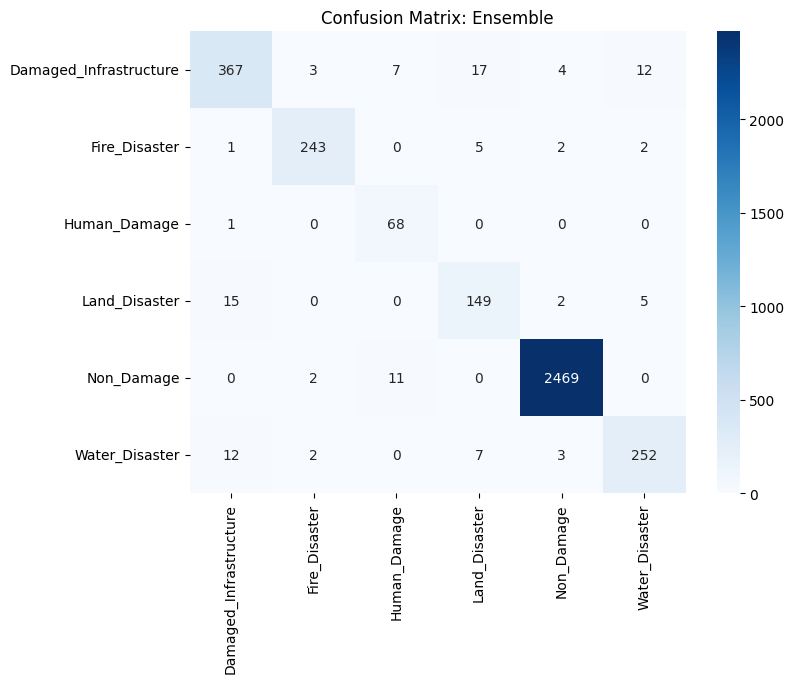

ViT Epoch 1/5:   0%|          | 0/458 [00:00<?, ?it/s]

ViT Epoch 2/5:   0%|          | 0/458 [00:00<?, ?it/s]

ViT Epoch 3/5:   0%|          | 0/458 [00:00<?, ?it/s]

ViT Epoch 4/5:   0%|          | 0/458 [00:00<?, ?it/s]

ViT Epoch 5/5:   0%|          | 0/458 [00:00<?, ?it/s]

Evaluating ViT:   0%|          | 0/115 [00:00<?, ?it/s]


Accuracy (ViT): 95.08%
                        precision    recall  f1-score   support

Damaged_Infrastructure       0.92      0.83      0.87       410
         Fire_Disaster       0.90      0.94      0.92       253
          Human_Damage       0.70      0.93      0.80        69
         Land_Disaster       0.78      0.83      0.81       171
            Non_Damage       1.00      0.99      0.99      2482
        Water_Disaster       0.83      0.89      0.86       276

              accuracy                           0.95      3661
             macro avg       0.86      0.90      0.88      3661
          weighted avg       0.95      0.95      0.95      3661



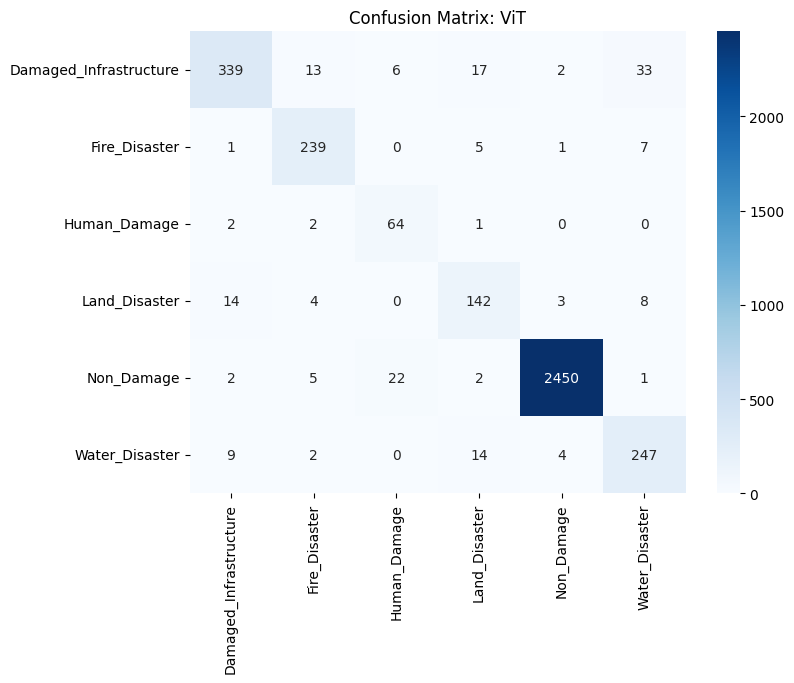

In [15]:
train_and_save_model(ens_model, "Ensemble", '/content/drive/MyDrive/Disaster_mng/disaster_ensemble.pth', train_loader, val_loader, weights_tensor, classes,10)
train_and_save_model(vit_model, "ViT", '/content/drive/MyDrive/Disaster_mng/disaster_vit.pth', train_loader, val_loader, weights_tensor, classes)

In [ ]:
train_and_save_model(vit_model, "ViT", '/content/drive/MyDrive/Disaster_mng/disaster_vit.pth', train_loader, val_loader, weights_tensor, classes)

**LOAD PRETRAINED MODELS**

In [16]:
def load_production_models(ens_path, vit_path, num_classes):
    ens_model = DisasterEnsemble(num_classes, pretrained=False).to(device)
    ens_model.load_state_dict(torch.load(ens_path, map_location=device))
    ens_model.eval()
    vit_model = create_vit_model(num_classes, pretrained=False).to(device)
    vit_model.load_state_dict(torch.load(vit_path, map_location=device))
    vit_model.eval()
    return ens_model, vit_model

**SEVERITY CALCULATION**

In [17]:
def calculate_severity(label, confidence):
    if label == "Non_Damage" or confidence < 0.75:
        return "Non_Damage", "Safe / No Damage Detected"
    if confidence >= 0.85:
        return label, "CRITICAL"
    elif confidence >= 0.65:
        return label, "MODERATE"
    else:
        return "Non_Damage", "Safe / No Damage Detected"

**IMAGE TESTING**

In [18]:
def tta_inference(model, pil_image, classes, num_augmentations=5):
    base_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    tta_transform = transforms.Compose([
        transforms.Resize((240, 240)),
        transforms.RandomCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    tensors = [base_transform(pil_image)]
    for _ in range(num_augmentations):
        tensors.append(tta_transform(pil_image))
    batch_tensor = torch.stack(tensors).to(device)
    with torch.no_grad():
        outputs = model(batch_tensor)
        probs = F.softmax(outputs, dim=1)
        avg_probs = torch.mean(probs, dim=0)
        score, idx = torch.max(avg_probs, dim=0)
    return classes[idx.item()], score.item()

**LIVE UI FOR CAMERA AND UPLOADS**

In [19]:
def launch_live_ui(ens_model, vit_model, classes):
    def process_gui_image(img):
        if img is None:
            return "Awaiting Image...", "N/A"
        ens_label, ens_score = tta_inference(ens_model, img, classes)
        vit_label, vit_score = tta_inference(vit_model, img, classes)
        if ens_label == vit_label:
            final_label = ens_label
            final_score = max(ens_score, vit_score)
        else:
            if ens_score > vit_score:
                final_label, final_score = ens_label, ens_score
            else:
                final_label, final_score = vit_label, vit_score

        final_label, final_severity = calculate_severity(final_label, final_score)
        return f"{final_label} (Confidence: {final_score:.2f})", final_severity

    ui = gr.Interface(
        fn=process_gui_image,
        inputs=gr.Image(sources=["upload", "webcam"], type="pil", label="Input Source"),
        outputs=[
            gr.Textbox(label="Disaster Type Classification"),
            gr.Textbox(label="Severity Assessment")
        ],
        title="Live Disaster & Severity Analysis System",
        description="Upload an image or use your webcam. Safe/Unknown objects are classified as 'Non_Damage'."
    )
    ui.launch(debug=True)

**RUN PROJECT**

In [ ]:
classes = ['Damaged_Infrastructure', 'Fire_Disaster', 'Human_Damage', 'Non_Damage', 'Water_Disaster', 'Land_Disaster']
prod_ensemble, prod_vit = load_production_models('/content/drive/MyDrive/Disaster_mng/disaster_ensemble.pth', '/content/drive/MyDrive/Disaster_mng/disaster_vit.pth', len(classes))
launch_live_ui(prod_ensemble, prod_vit, classes)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://685cac7378c6ebb73d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
